### Code for Figure 1

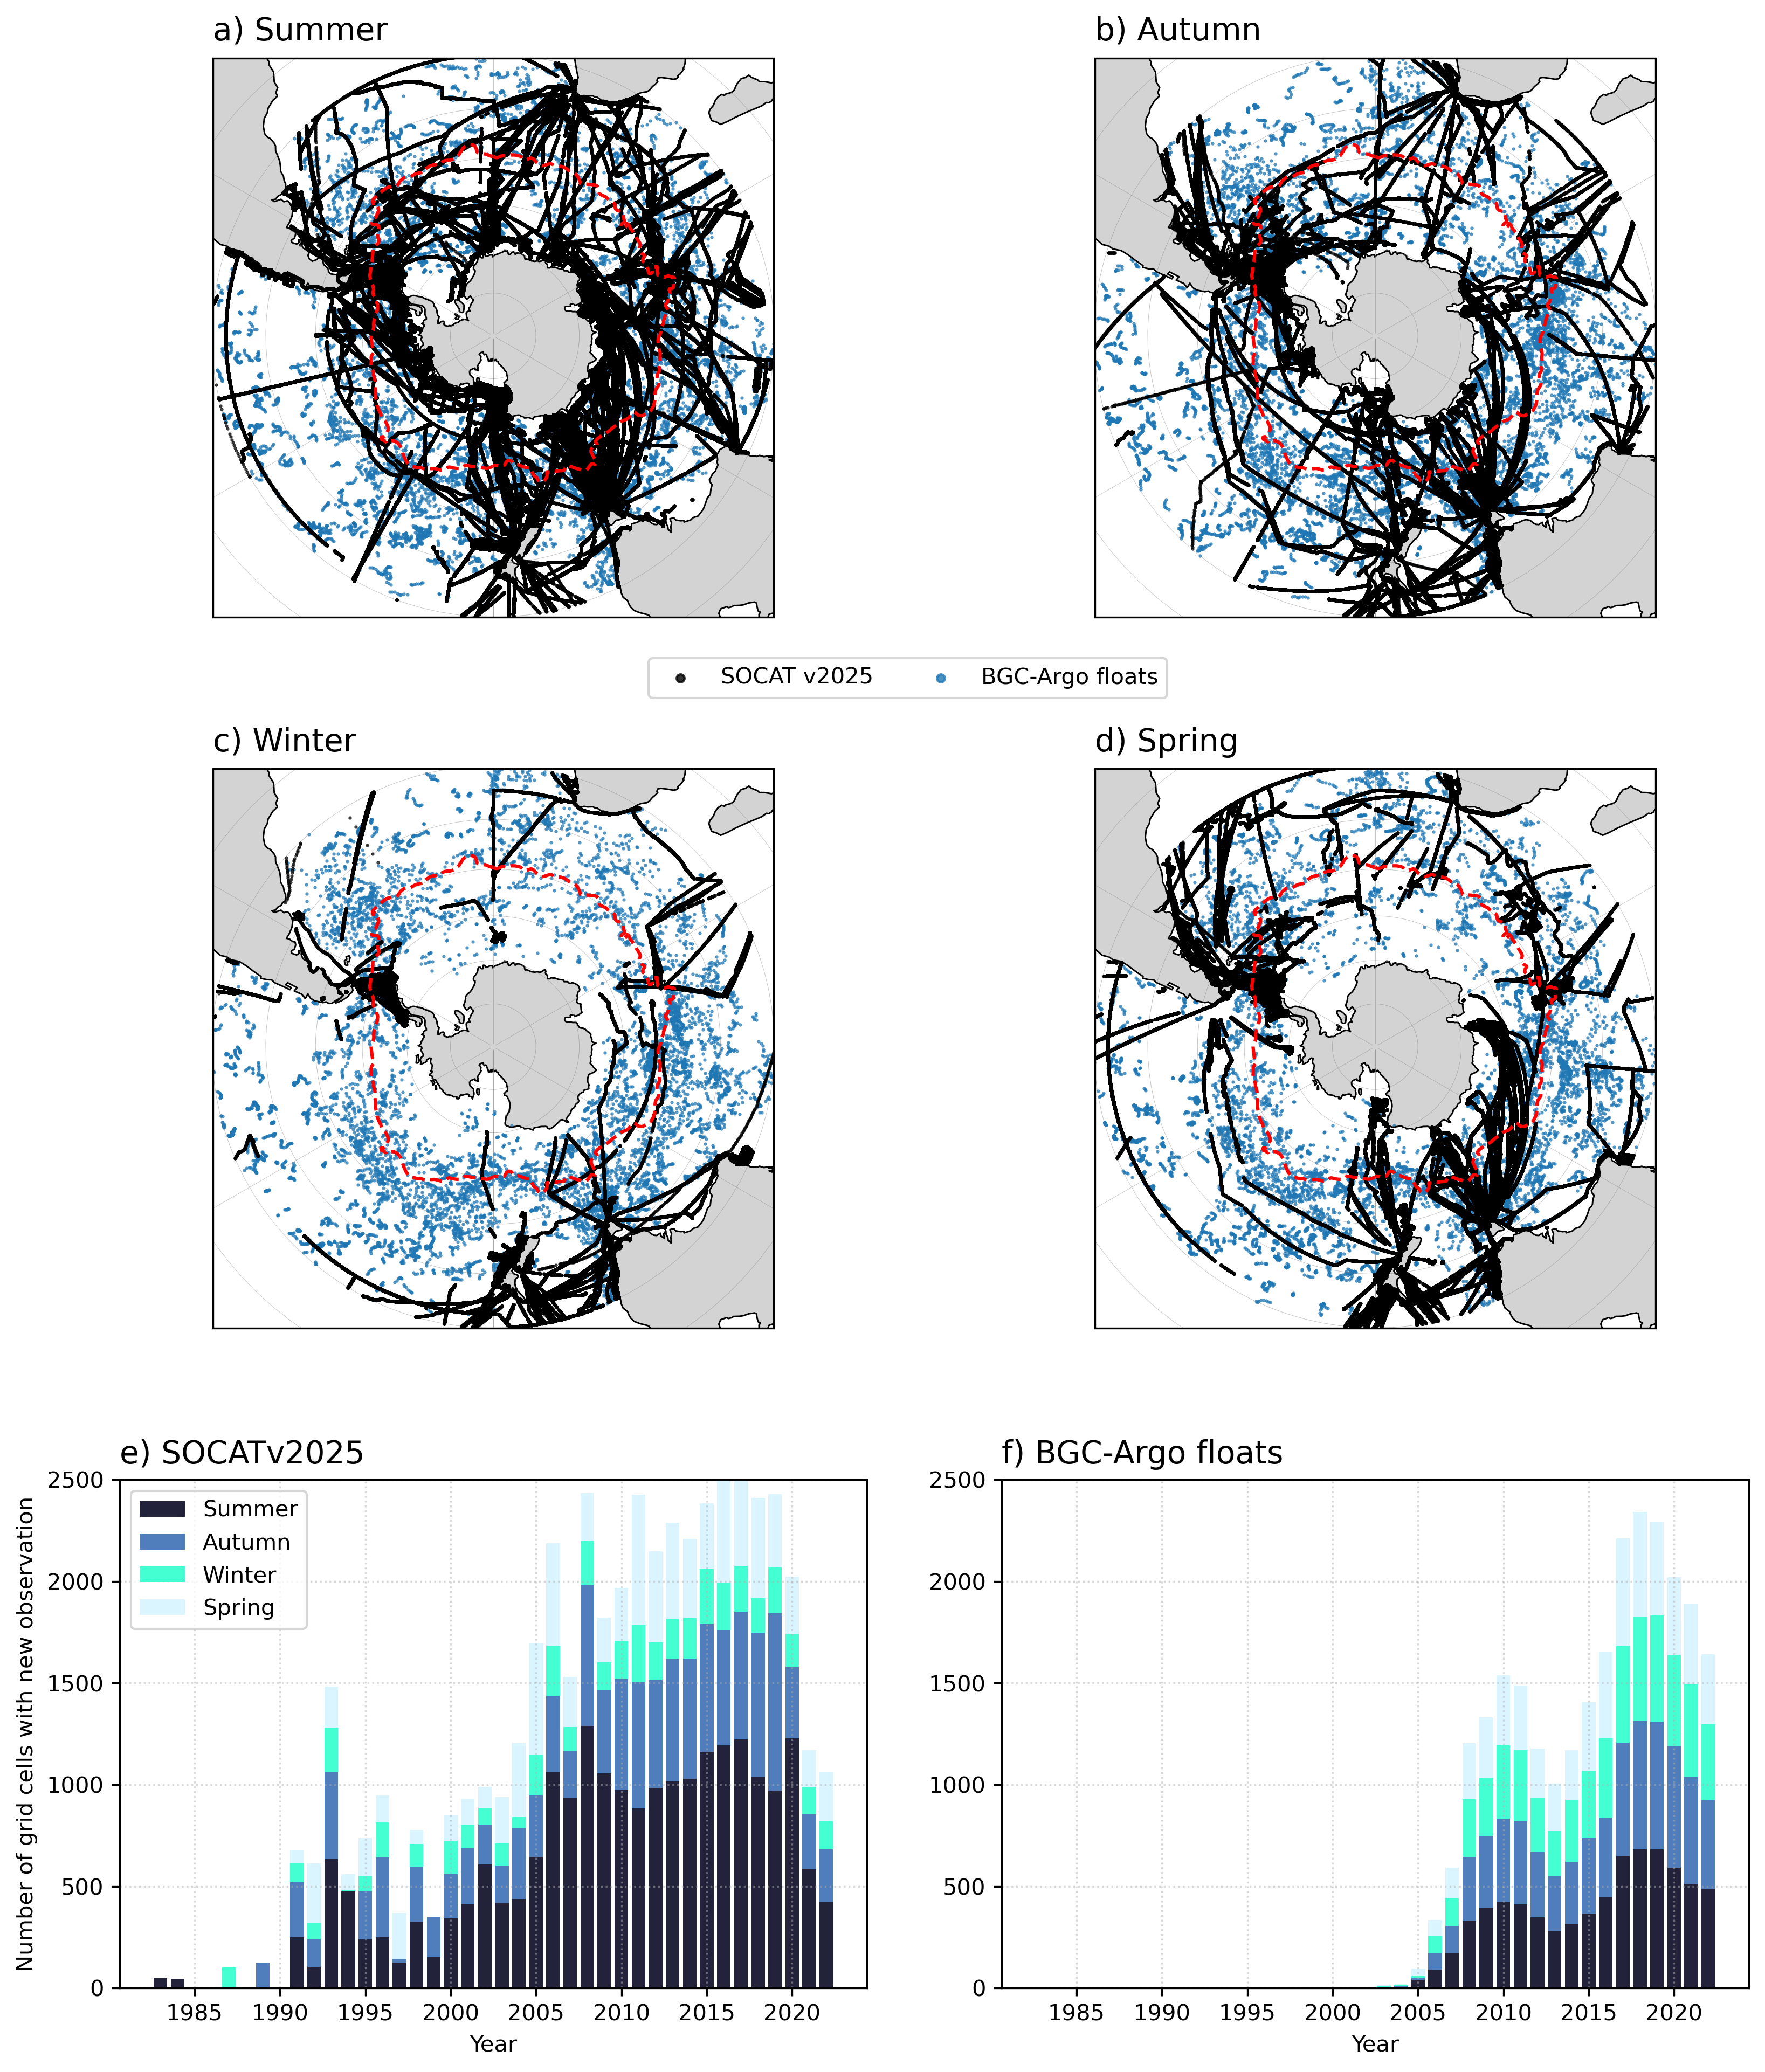

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# PATHS
# ============================================================
socat_path = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/"
    "MODEL_SOCAT_ONLY_OBS_v2/processing_steps/SOCATv2025_SO_clean_without_ind_expocodes.csv"
)
bgc_path = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/"
    "BGC-ARGO_surface_0_10m_pco2_temp_sal_all_profiles.csv"
)
fronts_path = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/fronts/62985.nc"

outfig = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/Fig1.png"
date_max = "2022-12-31"
lat_max = -30  # keep south of this latitude

# ============================================================
# LOAD DATA
# ============================================================
df_socat = pd.read_csv(socat_path, low_memory=False)
df_bgc = pd.read_csv(bgc_path, low_memory=False)
fronts = xr.load_dataset(fronts_path)

# ============================================================
# DATES
#   SOCAT: year/month/day columns -> date
#   BGC : datetime column -> date
# ============================================================
df_socat["date"] = pd.to_datetime(
    dict(year=df_socat["year"], month=df_socat["month"], day=df_socat["day"]),
    errors="coerce",
)
df_bgc["date"] = pd.to_datetime(df_bgc["datetime"], errors="coerce")

# drop bad dates
df_socat = df_socat[df_socat["date"].notna()].copy()
df_bgc = df_bgc[df_bgc["date"].notna()].copy()

# time cut
df_socat = df_socat[df_socat["date"] <= date_max].copy()
df_bgc = df_bgc[df_bgc["date"] <= date_max].copy()

# derive year/month consistently (avoid KeyError)
df_socat["year"] = df_socat["date"].dt.year
df_socat["month"] = df_socat["date"].dt.month

df_bgc["year"] = df_bgc["date"].dt.year
df_bgc["month"] = df_bgc["date"].dt.month

# ============================================================
# RESTRICT LATITUDE COVERAGE
# ============================================================
df_bgc = df_bgc[df_bgc["latitude"] <= lat_max].copy()
df_socat = df_socat[df_socat["latitude"] <= lat_max].copy()

# ============================================================
# SEASONS (as in original definition)
# ============================================================
season_defs = {
    "Summer": [12, 1, 2],
    "Autumn": [3, 4, 5],
    "Winter": [6, 7, 8],
    "Spring": [9, 10, 11],
}

season_colors = {
    "Summer": "#22223b",
    "Autumn": "#507dbc",
    "Winter": "#43ffd2",
    "Spring": "#daf5ff",
}

def month_to_season(m):
    for s, months in season_defs.items():
        if int(m) in months:
            return s
    return np.nan

df_socat["season"] = df_socat["month"].apply(month_to_season)
df_bgc["season"] = df_bgc["month"].apply(month_to_season)

# ============================================================
# GRID definition (1°x1°)
# ============================================================
def add_gridcell(df):
    df = df.copy()
    df["lon_grid"] = np.floor(df["longitude"].astype(float))
    df["lat_grid"] = np.floor(df["latitude"].astype(float))
    return df

df_socat = add_gridcell(df_socat)
df_bgc = add_gridcell(df_bgc)

# ============================================================
# YEARLY GRID-CELL COVERAGE (stacked histograms)
# ============================================================
def compute_yearly_counts(df):
    records = []
    for (year, season), g in df.groupby(["year", "season"], dropna=True):
        unique_cells = g[["lon_grid", "lat_grid"]].drop_duplicates()
        records.append({"year": int(year), "season": season, "n_cells": len(unique_cells)})

    out = pd.DataFrame(records)
    if out.empty:
        pivot = pd.DataFrame(columns=list(season_defs.keys()))
        pivot.index.name = "year"
        return pivot

    pivot = out.pivot(index="year", columns="season", values="n_cells").fillna(0)

    # ensure all seasons exist + consistent order
    for s in season_defs.keys():
        if s not in pivot.columns:
            pivot[s] = 0

    pivot = pivot[list(season_defs.keys())]
    return pivot.sort_index()

socat_seasonal = compute_yearly_counts(df_socat)
bgc_seasonal = compute_yearly_counts(df_bgc)

# unified year axis
min_year = int(min(socat_seasonal.index.min(), bgc_seasonal.index.min()))
max_year = int(max(socat_seasonal.index.max(), bgc_seasonal.index.max()))
all_years = np.arange(min_year, max_year + 1)

socat_seasonal = socat_seasonal.reindex(all_years, fill_value=0)
bgc_seasonal = bgc_seasonal.reindex(all_years, fill_value=0)

# ============================================================
# HELPERS: Orsi fronts plotting (handles 0..360 lon, NaNs, dateline jumps)
# ============================================================
def lon360_to_lon180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def plot_front_line(ax, lon, lat, *, jump_deg=20, **plot_kwargs):
    lon = np.asarray(lon).astype(float)
    lat = np.asarray(lat).astype(float)

    m = np.isfinite(lon) & np.isfinite(lat)
    lon = lon[m]
    lat = lat[m]

    lon = lon360_to_lon180(lon)
    if lon.size < 2:
        return

    dlon = np.abs(np.diff(lon))
    breaks = np.where(dlon > jump_deg)[0] + 1
    idxs = np.concatenate(([0], breaks, [lon.size]))

    for a, b in zip(idxs[:-1], idxs[1:]):
        if b - a < 2:
            continue
        ax.plot(lon[a:b], lat[a:b], transform=ccrs.PlateCarree(), **plot_kwargs)

# ============================================================
# Seasonal subsets for maps
# ============================================================
summer_months = [12, 1, 2]
autumn_months = [3, 4, 5]
winter_months = [6, 7, 8]
spring_months = [9, 10, 11]

df_socat_summer = df_socat[df_socat["month"].isin(summer_months)]
df_socat_autumn = df_socat[df_socat["month"].isin(autumn_months)]
df_socat_winter = df_socat[df_socat["month"].isin(winter_months)]
df_socat_spring = df_socat[df_socat["month"].isin(spring_months)]

df_bgc_summer = df_bgc[df_bgc["month"].isin(summer_months)]
df_bgc_autumn = df_bgc[df_bgc["month"].isin(autumn_months)]
df_bgc_winter = df_bgc[df_bgc["month"].isin(winter_months)]
df_bgc_spring = df_bgc[df_bgc["month"].isin(spring_months)]

# ============================================================
# PLOTTING
# ============================================================
fig = plt.figure(figsize=(13, 15.5), dpi=300)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1.1, 1.1, 1.0],
    hspace=0.28,
    wspace=0.18,
)

def south_polar_map(ax, letter_title, df_socat_season, df_bgc_season, fronts=None):
    ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

    socat_sc = ax.scatter(
        df_socat_season["longitude"], df_socat_season["latitude"],
        s=1, c="k", marker=".", alpha=0.8, transform=ccrs.PlateCarree(),
        label="SOCAT v2025", zorder=2
    )
    bgc_sc = ax.scatter(
        df_bgc_season["longitude"], df_bgc_season["latitude"],
        s=1, c="tab:blue", marker=".", alpha=0.8, transform=ccrs.PlateCarree(),
        label="BGC-Argo floats", zorder=1
    )

    if fronts is not None and ("LonPF" in fronts.variables) and ("LatPF" in fronts.variables):
        plot_front_line(
            ax,
            fronts["LonPF"].values,
            fronts["LatPF"].values,
            jump_deg=20,
            linewidth=1.5,
            linestyle="--",
            color="r",
            zorder=50
        )

    ax.text(0, 1.02, letter_title, transform=ax.transAxes, fontsize=14, va="bottom")
    return socat_sc, bgc_sc

# (a) Summer
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
h_socat, h_bgc = south_polar_map(ax_a, "a) Summer", df_socat_summer, df_bgc_summer, fronts=fronts)

# (b) Autumn
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.SouthPolarStereo())
south_polar_map(ax_b, "b) Autumn", df_socat_autumn, df_bgc_autumn, fronts=fronts)

# (c) Winter
ax_c = fig.add_subplot(gs[1, 0], projection=ccrs.SouthPolarStereo())
south_polar_map(ax_c, "c) Winter", df_socat_winter, df_bgc_winter, fronts=fronts)

# (d) Spring
ax_d = fig.add_subplot(gs[1, 1], projection=ccrs.SouthPolarStereo())
south_polar_map(ax_d, "d) Spring", df_socat_spring, df_bgc_spring, fronts=fronts)

# legend for symbols
fig.legend(
    handles=[h_socat, h_bgc],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.645),
    ncol=2,
    frameon=True,
    fontsize=10,
    markerscale=7,
)

# (e) SOCAT seasonal stacked
ax_e = fig.add_subplot(gs[2, 0])
bottom = np.zeros(len(all_years))
for season in ["Summer", "Autumn", "Winter", "Spring"]:
    ax_e.bar(
        all_years,
        socat_seasonal[season].values,
        bottom=bottom,
        label=season,
        color=season_colors[season],
        width=0.8,
    )
    bottom += socat_seasonal[season].values

ax_e.set_ylabel("Number of grid cells with new observation")
ax_e.set_xlabel("Year")
ax_e.grid(True, linestyle=":", alpha=0.5)
ax_e.text(0, 1.08, "e) SOCATv2025", transform=ax_e.transAxes, fontsize=14, va="top")
ax_e.set_ylim(0, 2500)
ax_e.legend(loc="upper left")

# (f) BGC-Argo seasonal stacked
ax_f = fig.add_subplot(gs[2, 1])
bottom = np.zeros(len(all_years))
for season in ["Summer", "Autumn", "Winter", "Spring"]:
    ax_f.bar(
        all_years,
        bgc_seasonal[season].values,
        bottom=bottom,
        label=season,
        color=season_colors[season],
        width=0.8,
    )
    bottom += bgc_seasonal[season].values

ax_f.set_xlabel("Year")
ax_f.grid(True, linestyle=":", alpha=0.5)
ax_f.text(0, 1.08, "f) BGC-Argo floats", transform=ax_f.transAxes, fontsize=14, va="top")
ax_f.set_ylim(0, 2500)

plt.savefig(outfig, dpi=300)
plt.show()